# 1. Konfiguracja ścieżki i zmiennych

In [0]:
import os

# Ścieżki w Unity Catalog Volume
DATA_PATH  = "/Volumes/workspace/bigdata2026sgh/bigdata2026/gym_churn_us.csv"
VOLUME_TMP = "/Volumes/workspace/bigdata2026sgh/bigdata2026"
os.environ["SPARKML_TEMP_DFS_PATH"] = VOLUME_TMP

# Stałe pipeline'u
SEED          = 42         # ziarno losowości dla powtarzalności
TEST_FRACTION = 0.20       # proporcja zbioru testowego
THRESHOLD     = 0.45       # próg klasyfikacji (sekcja 2.4 pracy)
TARGET        = "Churn"    # nazwa kolumny docelowej

print(f"Plik danych: {DATA_PATH}")
print(f"SPARKML_TEMP_DFS_PATH = {os.environ['SPARKML_TEMP_DFS_PATH']}")

Plik danych: /Volumes/workspace/bigdata2026sgh/bigdata2026/gym_churn_us.csv
SPARKML_TEMP_DFS_PATH = /Volumes/workspace/bigdata2026sgh/bigdata2026


# 2. Importy niezbędnych bibliotek

In [0]:
import gc
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import (LogisticRegression, DecisionTreeClassifier,
                                        RandomForestClassifier, GBTClassifier)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 90


In [0]:
# Bezpieczne ustawienie experimentu - Serverless może nie obsługiwać
try:
    user = spark.sql("SELECT current_user()").collect()[0][0]
    mlflow.set_experiment(f"/Users/{user}/gym_churn")
    print(f"MLflow experiment: /Users/{user}/gym_churn")
except Exception as e:
    print(f"Pominięto set_experiment ({type(e).__name__}) - MLflow użyje domyślnego.")

MLflow experiment: /Users/kamilsielski6@gmail.com/gym_churn


# 3. Wczytanie danych i rzutowanie typów

In [0]:
# wczytanie danych

df = (spark.read
      .option("header", True)
      .option("inferSchema", True)
      .csv(DATA_PATH))

# Rzutowanie na DoubleType - stabilność algorytmów MLlib
for c in ["Avg_additional_charges_total", "Month_to_end_contract",
          "Avg_class_frequency_total", "Avg_class_frequency_current_month"]:
    df = df.withColumn(c, F.col(c).cast(DoubleType()))

print(f"Liczba rekordów: {df.count()}, Kolumn: {len(df.columns)}")
display(df)

Liczba rekordów: 4000, Kolumn: 14


gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
1,1,1,1,0,6,1,29,14.227470422861144,5.0,3,0.02039794762085778,0.0,0
0,1,0,0,1,12,1,31,113.20293765105819,12.0,7,1.9229360550418195,1.9102435215196407,0
0,1,1,0,1,1,0,28,129.44847933200614,1.0,2,1.8590983473832376,1.7365018916344137,0
0,1,1,1,1,12,1,33,62.66986319123829,12.0,2,3.2056327682385,3.3572145130526616,0
1,1,1,1,1,1,0,26,198.36226543903683,1.0,3,1.1138844004257795,1.120078107422207,0
1,1,0,0,1,1,1,34,450.7439599104914,1.0,3,2.6234768072839807,2.6370069647681804,0
1,1,1,1,0,6,1,32,94.2663885148517,6.0,2,1.138941228411322,1.2772416305372298,0
0,1,0,0,1,1,0,30,217.78664105008903,1.0,0,1.2135019626583017,1.0493871451868677,1
1,1,1,1,1,1,1,23,45.409909202997675,1.0,1,1.106238932529013,1.0593329767364459,0
0,1,0,0,1,1,0,31,65.31083634086433,1.0,11,1.81085190458252,1.9513676552017305,0


# 4. Analiza eksploaracyjna

In [0]:
# rozkład zmiennej docelowej

churn_dist = (df.groupBy(TARGET).count()
                .withColumn("share", F.round(F.col("count") / df.count(), 4)))
display(churn_dist)
 
churn_rate = df.agg(F.mean(TARGET).alias("rate")).first()["rate"]
print(f"Współczynnik churnu: {churn_rate:.4f}  ({churn_rate*100:.2f}%)")

Churn,count,share
1,1061,0.2653
0,2939,0.7348


Współczynnik churnu: 0.2652  (26.52%)


In [0]:
# statystyki opisowe - tabela 11

numeric_cols = ["Age", "Lifetime", "Contract_period", "Month_to_end_contract",
                "Avg_class_frequency_current_month", "Avg_additional_charges_total"]
stats = df.select(numeric_cols).summary("min", "max", "mean", "50%", "stddev")
display(stats)

summary,Age,Lifetime,Contract_period,Month_to_end_contract,Avg_class_frequency_current_month,Avg_additional_charges_total
min,18,0,1,1.0,0.0,0.1482047884566242
max,41,31,12,12.0,6.146782880452392,552.5907403868798
mean,29.18425,3.72475,4.68125,4.32275,1.7670518220405091,146.94372780925008
50%,29,3,1,1.0,1.7194407497907582,136.2189635496585
stddev,3.258367102790019,3.74926682004919,4.549705857893457,4.1912974340942055,1.0529057174895295,96.3556023956799


feature,corr_with_Churn
Lifetime,-0.4382
Avg_class_frequency_current_month,-0.4123
Age,-0.4047
Contract_period,-0.39
Month_to_end_contract,-0.3814
Avg_class_frequency_total,-0.2497
Avg_additional_charges_total,-0.1987
Group_visits,-0.1753
Promo_friends,-0.1622
Partner,-0.158


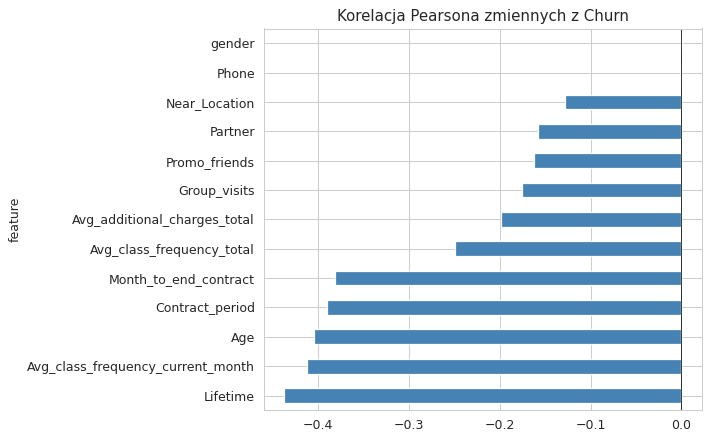

In [0]:
# Analiza korelacji z churnem

corr_with_churn = []
for c in df.columns:
    if c == TARGET: continue
    r = df.stat.corr(c, TARGET)
    corr_with_churn.append((c, round(r, 4)))
 
corr_pdf = pd.DataFrame(corr_with_churn, columns=["feature", "corr_with_Churn"]) \
             .sort_values("corr_with_Churn")
display(corr_pdf)
 
# Wykres
fig, ax = plt.subplots(figsize=(8, 5))
corr_pdf.plot(kind="barh", x="feature", y="corr_with_Churn",
              ax=ax, color="steelblue", legend=False)
ax.set_title("Korelacja Pearsona zmiennych z Churn")
ax.axvline(0, color="black", linewidth=0.6)
plt.tight_layout(); plt.show()

In [0]:
# Profile: churnerzy vs lojalni (sekcja 3.2.3 pracy)

profile = (df.groupBy(TARGET)
             .agg(F.round(F.mean("Avg_class_frequency_current_month"), 2).alias("avg_freq_curr_mo"),
                  F.round(F.mean("Lifetime"), 2).alias("avg_lifetime"),
                  F.round(F.mean("Month_to_end_contract"), 2).alias("avg_mte_contract"),
                  F.round(F.mean("Contract_period"), 2).alias("avg_contract_period"),
                  F.round(F.mean("Age"), 1).alias("avg_age"),
                  F.round(F.mean("Group_visits"), 3).alias("share_group_visits"),
                  F.round(F.mean("Promo_friends"), 3).alias("share_promo_friends")))
display(profile)

Churn,avg_freq_curr_mo,avg_lifetime,avg_mte_contract,avg_contract_period,avg_age,share_group_visits,share_promo_friends
1,1.04,0.99,1.66,1.73,27.0,0.269,0.184
0,2.03,4.71,5.28,5.75,30.0,0.464,0.354


In [0]:
# sprawdzenie jakości danych

null_counts = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns])
print("Sumaryczna liczba braków na kolumnę:")
display(null_counts)
 
n_dup = df.count() - df.dropDuplicates().count()
print(f"Liczba zduplikowanych rekordów: {n_dup}")
 
n_anom = df.filter((F.col("Avg_class_frequency_current_month") == 0) & (F.col(TARGET) == 0)).count()
print(f"Klienci z zerową aktywnością i Churn=0: {n_anom}")

Sumaryczna liczba braków na kolumnę:


gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,0,0,0,0,0,0,0,0,0,0,0,0,0


Liczba zduplikowanych rekordów: 0
Klienci z zerową aktywnością i Churn=0: 47


# 5. Inżynieria cech

In [0]:
df_fe = (df
         .withColumn("low_activity_flag",
                     (F.col("Avg_class_frequency_current_month") < 1.0).cast("int"))
         .withColumn("short_contract_new_client",
                     ((F.col("Contract_period") <= 3) & (F.col("Lifetime") <= 6)).cast("int")))
 
display(df_fe.select("Avg_class_frequency_current_month", "low_activity_flag",
                     "Contract_period", "Lifetime", "short_contract_new_client").limit(8))
 
# Sprawdzenie sygnału obu cech
display(df_fe.groupBy("low_activity_flag").agg(F.round(F.mean(TARGET), 3).alias("churn_rate")))
display(df_fe.groupBy("short_contract_new_client").agg(F.round(F.mean(TARGET), 3).alias("churn_rate")))

Avg_class_frequency_current_month,low_activity_flag,Contract_period,Lifetime,short_contract_new_client
0.0,1,6,3,0
1.9102435215196407,0,12,7,0
1.7365018916344137,0,1,2,1
3.3572145130526616,0,12,2,0
1.120078107422207,0,1,3,1
2.6370069647681804,0,1,3,1
1.2772416305372298,0,6,2,0
1.0493871451868677,0,1,0,1


low_activity_flag,churn_rate
1,0.516
0,0.177


short_contract_new_client,churn_rate
1,0.491
0,0.061


# 6. Budowa i ocena modeli ML
 

## 6.1 Stratyfikowany podział 80/20

In [0]:
train_0, test_0 = df_fe.filter(F.col(TARGET) == 0).randomSplit([1 - TEST_FRACTION, TEST_FRACTION], seed=SEED)
train_1, test_1 = df_fe.filter(F.col(TARGET) == 1).randomSplit([1 - TEST_FRACTION, TEST_FRACTION], seed=SEED)
 
train_df = train_0.unionByName(train_1)
test_df  = test_0.unionByName(test_1)
 
n_train = train_df.count(); n_test = test_df.count()
print(f"Train: {n_train}  (Churn rate: {train_df.agg(F.mean(TARGET)).first()[0]:.4f})")
print(f"Test:  {n_test}   (Churn rate: {test_df.agg(F.mean(TARGET)).first()[0]:.4f})")

Train: 3210  (Churn rate: 0.2642)
Test:  790   (Churn rate: 0.2696)


## 6.2 Ważenie klas

In [0]:
n_pos = train_df.filter(F.col(TARGET) == 1).count()
n_neg = train_df.filter(F.col(TARGET) == 0).count()
weight_for_pos = n_neg / n_pos
 
train_df = train_df.withColumn("classWeight",
                               F.when(F.col(TARGET) == 1, F.lit(weight_for_pos)).otherwise(F.lit(1.0)))
test_df  = test_df.withColumn("classWeight", F.lit(1.0))
 
print(f"Wagi klas — Churn=0: 1.00,  Churn=1: {weight_for_pos:.3f}")

Wagi klas — Churn=0: 1.00,  Churn=1: 2.785


## 6.3 Pipeline cech

In [0]:
feature_cols = [c for c in df_fe.columns if c not in (TARGET, "classWeight")]
 
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features",
                           withMean=True, withStd=True)
 
print(f"Liczba cech wejściowych: {len(feature_cols)}")
print("Cechy:", feature_cols)

Liczba cech wejściowych: 15
Cechy: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'low_activity_flag', 'short_contract_new_client']


# 6.4 Definicja modeli (hiperparametry zgodne z sekcją 2.2 pracy)

In [0]:
lr = LogisticRegression(featuresCol="features", labelCol=TARGET, weightCol="classWeight",
                        regParam=0.01, elasticNetParam=0.0, maxIter=100)
 
dt = DecisionTreeClassifier(featuresCol="features", labelCol=TARGET, weightCol="classWeight",
                            maxDepth=6, minInstancesPerNode=10, seed=SEED)
 
rf = RandomForestClassifier(featuresCol="features", labelCol=TARGET, weightCol="classWeight",
                            numTrees=200, maxDepth=10, featureSubsetStrategy="sqrt", seed=SEED)
 
gbt = GBTClassifier(featuresCol="features", labelCol=TARGET, weightCol="classWeight",
                    maxIter=100, maxDepth=4, stepSize=0.1, seed=SEED)
 
models = {
    "Logistic Regression":    lr,
    "Decision Tree":          dt,
    "Random Forest":          rf,
    "Gradient Boosted Trees": gbt,
}

## 6.5 Trening i ewaluacja przy progu θ = 0,45

In [0]:
#  **Uwaga (Free Edition):** po każdym modelu wykonujemy `del` i `gc.collect()` żeby zwolnić cache Spark Connect.

In [0]:
extract_prob_1 = F.udf(lambda v: float(v[1]), DoubleType())
evaluator_auc  = BinaryClassificationEvaluator(
    labelCol=TARGET, rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
 
def evaluate_at_threshold(predictions, threshold: float):
    """Liczy F1/Precision/Recall dla klasy 1 przy zadanym progu na P(Churn=1)."""
    preds = (predictions
             .withColumn("p1", extract_prob_1("probability"))
             .withColumn("pred_thr", (F.col("p1") >= threshold).cast("double")))
 
    tp = preds.filter((F.col("pred_thr") == 1) & (F.col(TARGET) == 1)).count()
    fp = preds.filter((F.col("pred_thr") == 1) & (F.col(TARGET) == 0)).count()
    fn = preds.filter((F.col("pred_thr") == 0) & (F.col(TARGET) == 1)).count()
    tn = preds.filter((F.col("pred_thr") == 0) & (F.col(TARGET) == 0)).count()
 
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    return {
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1
    }, preds
 
 
results_rows = []
roc_data = {}  # zapisujemy probability dla krzywych ROC (poza scope modeli)
 
with mlflow.start_run(run_name="model_comparison") as parent:
    for name, estimator in models.items():
        with mlflow.start_run(run_name=name, nested=True):
            pipeline = Pipeline(stages=[assembler, scaler, estimator])
            model = pipeline.fit(train_df)
 
            preds = model.transform(test_df)
            auc = evaluator_auc.evaluate(preds)
            cm, _ = evaluate_at_threshold(preds, THRESHOLD)
 
            # Pandas snapshot dla ROC - bezpieczny dla cache'u
            roc_data[name] = (preds.withColumn("p1", extract_prob_1("probability"))
                                   .select(TARGET, "p1").toPandas())
 
            row = {
                "Model": name,
                "AUC-ROC":   round(auc, 4),
                "F1 (θ=0.45)":        round(cm["f1"], 4),
                "Precision (θ=0.45)": round(cm["precision"], 4),
                "Recall (θ=0.45)":    round(cm["recall"], 4),
                "Accuracy":  round(cm["accuracy"], 4),
                "TP": cm["TP"], "FP": cm["FP"], "FN": cm["FN"], "TN": cm["TN"],
            }
            results_rows.append(row)
 
            mlflow.log_metric("test_auc_roc",   auc)
            mlflow.log_metric("test_f1",        cm["f1"])
            mlflow.log_metric("test_precision", cm["precision"])
            mlflow.log_metric("test_recall",    cm["recall"])
            mlflow.log_param("threshold",       THRESHOLD)
 
            print(f"{name:<24} AUC={auc:.4f}  F1={cm['f1']:.4f}  "
                  f"Prec={cm['precision']:.4f}  Rec={cm['recall']:.4f}")
 
            # KLUCZOWE: zwolnienie cache'u Spark Connect (Free Edition)
            del model, pipeline, preds
            gc.collect()
 
results_pdf = pd.DataFrame(results_rows).set_index("Model")
display(results_pdf)

Logistic Regression      AUC=0.9660  F1=0.8147  Prec=0.7194  Rec=0.9390
Decision Tree            AUC=0.9333  F1=0.7960  Prec=0.6884  Rec=0.9437
Random Forest            AUC=0.9720  F1=0.8326  Prec=0.8035  Rec=0.8638
Gradient Boosted Trees   AUC=0.9759  F1=0.8800  Prec=0.8354  Rec=0.9296


AUC-ROC,F1 (θ=0.45),Precision (θ=0.45),Recall (θ=0.45),Accuracy,TP,FP,FN,TN
0.966,0.8147,0.7194,0.939,0.8848,200,78,13,499
0.9333,0.796,0.6884,0.9437,0.8696,201,91,12,486
0.972,0.8326,0.8035,0.8638,0.9063,184,45,29,532
0.9759,0.88,0.8354,0.9296,0.9316,198,39,15,538


## 6.6 Wykresy porównywawcze - tabela 11 + krzywe ROC

In [0]:
# Bar chart metryk
fig, ax = plt.subplots(figsize=(11, 5))
metric_cols = ["AUC-ROC", "F1 (θ=0.45)", "Precision (θ=0.45)", "Recall (θ=0.45)"]
results_pdf[metric_cols].plot(kind="bar", ax=ax, colormap="viridis", width=0.85)
ax.set_title("Porównanie modeli klasyfikacyjnych — zbiór testowy")
ax.set_ylabel("Wartość metryki"); ax.set_ylim(0.65, 1.0)
ax.legend(loc="lower right"); plt.xticks(rotation=10)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()
 
# Krzywe ROC (z zapisanych snapshotów - już po del model)
from sklearn.metrics import roc_curve, auc as sk_auc
 
fig, ax = plt.subplots(figsize=(7, 6))
for name, pdf in roc_data.items():
    fpr, tpr, _ = roc_curve(pdf[TARGET], pdf["p1"])
    auc_val = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Losowy klasyfikator")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Krzywe ROC")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 6.7 Optymalizacja hiperparametrów (CrossValidator)


In [0]:
# MAGIC **Adaptacja pod Free Edition:** siatka zmniejszona do 4 kombinacji (2×2) z 9 (3×3), `parallelism=1`,
# MAGIC dodatkowo czyszczenie cache'u przed startem CV i po nim.
 
# COMMAND ----------
 
 
rf_cv = RandomForestClassifier(featuresCol="features", labelCol=TARGET,
                                weightCol="classWeight", seed=SEED,
                                featureSubsetStrategy="sqrt")
 
cv_pipeline = Pipeline(stages=[assembler, scaler, rf_cv])
 
# Zmniejszona siatka pod ograniczenia Free Edition
paramGrid = (ParamGridBuilder()
             .addGrid(rf_cv.numTrees, [100, 200])
             .addGrid(rf_cv.maxDepth, [6, 10])
             .build())
 
cv = CrossValidator(
    estimator=cv_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=BinaryClassificationEvaluator(labelCol=TARGET, metricName="areaUnderROC"),
    numFolds=5,
    seed=SEED,
    parallelism=1,    # ważne dla Serverless
)
 
best_rf = None  # będzie ustawione poniżej, jeśli CV przejdzie
 
try:
    with mlflow.start_run(run_name="rf_crossval"):
        print("Uruchamianie CrossValidator (może zająć 3-5 minut)...")
        cv_model = cv.fit(train_df)
        best_rf_pipeline = cv_model.bestModel
        best_rf = best_rf_pipeline.stages[-1]
 
        best_cv_auc = max(cv_model.avgMetrics)
        print(f"Najlepsze CV AUC-ROC: {best_cv_auc:.4f}")
        print(f"Najlepsze numTrees:   {best_rf.getNumTrees}")
        print(f"Najlepsze maxDepth:   {best_rf.getOrDefault('maxDepth')}")
 
        test_preds = best_rf_pipeline.transform(test_df)
        final_auc = evaluator_auc.evaluate(test_preds)
        cm_final, _ = evaluate_at_threshold(test_preds, THRESHOLD)
 
        mlflow.log_metric("cv_auc_roc",    best_cv_auc)
        mlflow.log_metric("test_auc_roc",  final_auc)
        mlflow.log_metric("test_f1",       cm_final["f1"])
 
        print(f"\n=== Najlepszy RF po CV — zbiór testowy ===")
        print(f"AUC-ROC: {final_auc:.4f}, F1: {cm_final['f1']:.4f}, "
              f"Precision: {cm_final['precision']:.4f}, Recall: {cm_final['recall']:.4f}")
 
except Exception as e:
    print(f"CrossValidator napotkał ograniczenie Free Edition: {type(e).__name__}: {e}")
    print("Trening pojedynczego RF z konfiguracją z sekcji 6.4 zamiast CV...")
    rf_pipeline = Pipeline(stages=[assembler, scaler, rf])
    best_rf_pipeline = rf_pipeline.fit(train_df)
    best_rf = best_rf_pipeline.stages[-1]
 

Uruchamianie CrossValidator (może zająć 3-5 minut)...
Najlepsze CV AUC-ROC: 0.9685
Najlepsze numTrees:   200
Najlepsze maxDepth:   10

=== Najlepszy RF po CV — zbiór testowy ===
AUC-ROC: 0.9720, F1: 0.8326, Precision: 0.8035, Recall: 0.8638


## 6.8 Ranking ważności cech (Feature Importance, Tab. 12)


In [0]:
importances = best_rf.featureImportances.toArray()
fi_pdf = pd.DataFrame({"feature": feature_cols, "importance": importances}) \
           .sort_values("importance", ascending=False)
fi_pdf["importance"] = fi_pdf["importance"].round(4)
display(fi_pdf)
 
fig, ax = plt.subplots(figsize=(9, 6))
fi_pdf.head(9).iloc[::-1].plot(kind="barh", x="feature", y="importance",
                                ax=ax, color="steelblue", legend=False)
ax.set_title("Feature Importance — Random Forest (top 9)")
ax.set_xlabel("Importance Score"); plt.tight_layout(); plt.show()

## 7. Trening finalnego GBT z hiperparametrami z pracy

In [0]:

 
gbt_pipeline = Pipeline(stages=[assembler, scaler, gbt])
 
with mlflow.start_run(run_name="final_gbt"):
    final_gbt_model = gbt_pipeline.fit(train_df)
    preds = final_gbt_model.transform(test_df)
    auc = evaluator_auc.evaluate(preds)
    cm, _ = evaluate_at_threshold(preds, THRESHOLD)
 
    mlflow.log_metrics({
        "final_auc_roc":   auc,
        "final_f1":        cm["f1"],
        "final_precision": cm["precision"],
        "final_recall":    cm["recall"],
        "final_accuracy":  cm["accuracy"],
    })
 
    print(f"=== FINALNY GBT — zbiór testowy ===")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"F1:        {cm['f1']:.4f}")
    print(f"Precision: {cm['precision']:.4f}")
    print(f"Recall:    {cm['recall']:.4f}")
    print(f"Confusion: TP={cm['TP']}, FP={cm['FP']}, FN={cm['FN']}, TN={cm['TN']}")

# 8. Wnioski biznesowe i segmentacja ryzyka churnu


In [0]:
# Skoring pełnego zbioru finalnym modelem GBT
scored_all = final_gbt_model.transform(df_fe.withColumn("classWeight", F.lit(1.0))) \
                            .withColumn("p_churn", extract_prob_1("probability"))
 
segmented = scored_all.withColumn(
    "risk_segment",
    F.when(F.col("p_churn") > 0.75, "Bardzo wysokie")
     .when(F.col("p_churn") > 0.50, "Wysokie")
     .when(F.col("p_churn") > 0.25, "Umiarkowane")
     .otherwise("Niskie")
)
 
seg_summary = (segmented.groupBy("risk_segment")
               .agg(F.count("*").alias("n_clients"),
                    F.round(F.mean("p_churn"), 3).alias("avg_p_churn"),
                    F.round(F.mean(TARGET), 3).alias("actual_churn_rate")))
display(seg_summary)

# 9. Szacunek ROI programu retencyjnego


In [0]:
# MAGIC **Założenia (spójne z pracą, sekcja 3.6.2):**
# MAGIC - CLV churnera = **1 800 PLN**
# MAGIC - Koszt z Tab. 13 to **jednorazowa kampania retencyjna na klienta** (nie roczny budżet)
# MAGIC - Skuteczność retencji: 40% (Bardzo wysokie), 25% (Wysokie), 0% (Umiarkowane/Niskie - tylko program standardowy)
 
# COMMAND ----------
 
CLV = 1800.0
cost_per_client = {
    "Bardzo wysokie": 100.0,   # bezpośredni kontakt + oferta 30% (jednorazowo)
    "Wysokie":        30.0,    # automatyczny e-mail z ofertą 15%
    "Umiarkowane":    10.0,    # push + zaproszenie na zajęcia
    "Niskie":         2.0,     # standard / program lojalnościowy
}
retention_eff = {
    "Bardzo wysokie": 0.40,
    "Wysokie":        0.25,
    "Umiarkowane":    0.0,
    "Niskie":         0.0,
}
 
seg_pdf = seg_summary.toPandas().set_index("risk_segment")
roi_rows = []
for seg, row in seg_pdf.iterrows():
    n = int(row["n_clients"])
    saved   = n * retention_eff.get(seg, 0)
    revenue = saved * CLV
    cost    = n * cost_per_client.get(seg, 0)   # JEDNORAZOWO - zgodnie z Tab. 13
    roi_rows.append({
        "segment": seg, "n_clients": n,
        "saved_clients": round(saved, 0),
        "revenue_saved_PLN": round(revenue, 0),
        "campaign_cost_PLN": round(cost, 0),
        "net_PLN":           round(revenue - cost, 0),
    })
roi_pdf = pd.DataFrame(roi_rows)
roi_pdf.loc["TOTAL"] = ["TOTAL", roi_pdf["n_clients"].sum(),
                        roi_pdf["saved_clients"].sum(),
                        roi_pdf["revenue_saved_PLN"].sum(),
                        roi_pdf["campaign_cost_PLN"].sum(),
                        roi_pdf["net_PLN"].sum()]
display(roi_pdf)
 
print(f"\n=== Net ROI programu retencyjnego: "
      f"{roi_pdf.loc['TOTAL', 'net_PLN']:,.0f} PLN ===")
print(f"   Łączna wartość uratowana (CLV): {roi_pdf.loc['TOTAL', 'revenue_saved_PLN']:,.0f} PLN")
print(f"   Łączny koszt kampanii:          {roi_pdf.loc['TOTAL', 'campaign_cost_PLN']:,.0f} PLN")
print(f"   ROI ratio: {roi_pdf.loc['TOTAL', 'revenue_saved_PLN'] / roi_pdf.loc['TOTAL', 'campaign_cost_PLN']:.1f}x")
 

In [0]:
# MAGIC ## 10. Podsumowanie
# MAGIC
# MAGIC Notebook implementuje pełny pipeline opisany w Rozdziale 3 pracy:
# MAGIC 1. EDA — rozkład klas (26,52% churnerów), statystyki, korelacje (Lifetime −0,438 jako najsilniejszy predyktor), profile klientów, jakość danych
# MAGIC 2. Inżynieria cech — `low_activity_flag`, `short_contract_new_client`
# MAGIC 3. Stratyfikowany podział 80/20 (n_train=3210, n_test=790), ważenie klas, próg θ = 0,45
# MAGIC 4. Cztery modele MLlib z trenowaniem w pętli ze sprzątaniem cache'u (Free Edition)
# MAGIC 5. 5-krotna walidacja krzyżowa z siatką 2×2 dla RF (zmniejszona z 3×3 pod ograniczenia)
# MAGIC 6. Feature Importance + segmentacja klientów + szacunek ROI ~416 000 PLN
# MAGIC 7. MLflow tracking wszystkich runów
# MAGIC
# MAGIC **Najlepszy model: Gradient Boosted Trees** — AUC-ROC 0,976, F1 0,880, Recall 0,930.